# Cooler Simulation: Mathematical and Physical Foundations

This simulation models the thermal dynamics of a cooler using a lumped-capacitance approach. Instead of solving partial differential equations for spatial temperature distribution, the system tracks discrete, well-mixed nodes (Air, Food, Ice, Water, Cooler Wall) that interact continuously through coupled ordinary differential equations (ODEs) and dynamic geometry calculations.

---

## 1. Dynamic Geometry and Fluid Mechanics

Because heat transfer heavily relies on Newton's Law of Cooling ($\dot{Q} = h \cdot A \cdot \Delta T$), the simulation must accurately calculate the changing surface areas ($A$) at every time step. As ice melts, it shrinks; as water accumulates, it submerges the food and ice, fundamentally altering which mediums are exchanging heat.

### Volume and Solid Shrinkage (The 2/3 Power Law)
The solver first converts the current masses of ice and water into volumes using their respective densities ($V = m / \rho$). As the ice block melts, its volume decreases. Assuming the geometric aspect ratio of the individual ice chunks remains relatively constant, the total surface area scales non-linearly with volume according to the square-cube law:
$$ A_{ice\_total} = A_{init} \left( \frac{V_{ice}}{V_{init}} \right)^{2/3} $$

### The Iterative Buoyancy Model
If the cooler is undrained, meltwater pools at the bottom. The total water height ($h_{water}$) isn't just the volume of the water divided by the base area; it must account for the displacement caused by submerged ice and food (Archimedes' principle). The code uses a 5-step iterative loop to converge on the true water level.

*   **Ice Submersion:** Ice floats because $\rho_{ice} < \rho_{water}$. The ice draft (the depth it sinks to when floating) is:
    $$ \text{Draft}_{ice} = h_{ice\_bed} \left(\frac{\rho_{ice}}{\rho_{water}}\right) $$
    If $h_{water} > \text{Draft}_{ice}$, the ice is floating, and its submerged volume is strictly $V_{sub,ice} = m_{ice} / \rho_{water}$. Otherwise, it rests on the bottom and is only partially submerged.
*   **Food Submersion:** The food is evaluated to see if it sinks ($\rho_{food} > \rho_{water}$) or floats. 
*   **Water Level Update:** After calculating the displaced volumes, the new water height is:
    $$ h_{water} = \frac{V_{water} + V_{sub,ice} + V_{sub,food}}{A_{base}} $$

### Surface Partitioning and Contact Loss
The model calculates submersion fractions ($\phi$) for the ice and the food:
$$ \phi_{ice} = \frac{V_{sub,ice}}{V_{ice}} \quad \text{and} \quad \phi_{food} = \frac{V_{sub,food}}{V_{food}} $$
These fractions linearly partition the total surface areas into water-exposed and air-exposed dynamic areas (e.g., $A_{ice\_water} = A_{ice\_total} \cdot \phi_{ice}$). If the water level gets deep enough, the simulation assumes the food and ice float freely, breaking direct conductive contact ($A_{food\_ice} \to 0$).

### Air Volume Tracking
As solid ice melts into denser liquid water ($917 \text{ kg/m}^3 \to 1000 \text{ kg/m}^3$), the total volume of the contents shrinks. This slightly increases the internal air volume:
$$ V_{air} = V_{inner\_capacity} - V_{water} - V_{ice} - V_{food} $$
This ensures the thermal mass of the air ($m_{air} \cdot c_{p,air}$) remains physically accurate as the cooler empties.

---

## 2. The Ordinary Differential Equation (ODE) System

The simulation tracks 7 independent state variables simultaneously: $T_{cooler}$, $T_{air}$, $T_{food}$, $T_{ice}$, $T_{water}$, $m_{ice}$, and $m_{water}$. For any object undergoing sensible heating, the rate of change of its temperature is the net heat flow divided by its thermal mass:
$$ \frac{dT}{dt} = \frac{\dot{Q}_{in} - \dot{Q}_{out}}{m \cdot c_p} $$

### A. Cooler Wall ($dT_{cooler}/dt$)
The wall acts as a thermal buffer, modeled using a 1D steady-state thermal resistance network encompassing exterior convection, wall conduction, and interior convection.
$$ \frac{dT_{cooler}}{dt} = \frac{\dot{Q}_{ext \to wall} - \dot{Q}_{wall \to air}}{C_{cooler}} $$

### B. Food Temperature ($dT_{food}/dt$)
Food receives heat from the air (and from ambient blasts when the lid is open) and loses heat to the ice and meltwater.
$$ \frac{dT_{food}}{dt} = \frac{\dot{Q}_{air \to food} + \dot{Q}_{amb \to food} - \dot{Q}_{food \to ice} - \dot{Q}_{food \to water}}{m_{food} \cdot c_{p,food}} $$

### C. Ice Dynamics ($dT_{ice}/dt$ and $dm_{ice}/dt$)
The ODE employs piecewise logic based on the melting point ($T_{melt} = 0^\circ \text{C}$). Let $\dot{Q}_{into\_ice}$ be the sum of all heat entering the ice.
*   **Sub-cooled Ice ($T_{ice} < T_{melt}$):** All heat raises the temperature; mass is constant.
    $$ \frac{dT_{ice}}{dt} = \frac{\dot{Q}_{into\_ice}}{m_{ice} \cdot c_{p,ice}} \quad \text{and} \quad \frac{dm_{ice}}{dt} = 0 $$
*   **Melting Ice ($T_{ice} = T_{melt}$):** Temperature is constant. All heat drives the phase change dictated by the Latent Heat of Fusion ($L_f$).
    $$ \frac{dT_{ice}}{dt} = 0 \quad \text{and} \quad \frac{dm_{ice}}{dt} = -\frac{\max(0, \dot{Q}_{into\_ice})}{L_f} $$

### D. Meltwater Dynamics ($dT_{water}/dt$ and $dm_{water}/dt$)
*   **If Drained:** Meltwater instantly disappears: $\frac{dm_{water}}{dt} = 0$ and $\frac{dT_{water}}{dt} = 0$.
*   **If Undrained:** Water mass increases exactly as ice melts ($\frac{dm_{water}}{dt} = \dot{m}_{melt}$). The temperature equation accounts for net heat flow *and* the cooling effect of newly melted ice mixing into the pool:
    $$ \frac{dT_{water}}{dt} = \frac{\dot{Q}_{net, water} + \dot{m}_{melt} \cdot c_{p,water} \cdot (T_{melt} - T_{water})}{m_{water} \cdot c_{p,water}} $$

### E. Internal Air Temperature ($dT_{air}/dt$)
The air temperature derivative sums all internal convective interactions, plus two special fluxes:
$$ \frac{dT_{air}}{dt} = \frac{\dot{Q}_{wall \to air} - \dot{Q}_{air \to food} - \dot{Q}_{air \to ice} - \dot{Q}_{air \to water} + \dot{Q}_{exchange} + \dot{Q}_{infiltration}}{m_{air} \cdot c_{p,air}} $$
*   **$\dot{Q}_{exchange}$:** A massive continuous mass exchange flux applied when the cooler lid is open ($\dot{m}_{air} \cdot c_{p,air} \cdot (T_{ambient} - T_{air})$).
*   **$\dot{Q}_{infiltration}$:** When the cooler is drained, losing water volume creates a vacuum that pulls warm ambient air inside.

---

## 3. Integration Methodology

Because the internal air has a very low thermal mass, its temperature can fluctuate in a fraction of a second, while the solid ice takes days to melt. This creates a mathematically **stiff** ODE system. The simulation uses SciPy's `Radau` solver, an implicit Runge-Kutta method specifically engineered to maintain numerical stability and prevent divergence when integrating stiff differential equations.

---

## 4. Capabilities and Limitations

**Capabilities:**
*   **Dynamic Phase Tracking:** Seamlessly transitions between sensible heating of sub-cooled ice and latent melting without requiring discrete state machine jumps.
*   **Drained vs. Undrained Evaluation:** Accurately models the divergent physics of retaining a cold water bath versus losing thermal mass and sucking in warm air via infiltration.
*   **Realistic Geometry:** Adjusts interaction areas accurately as ice dwindles and water levels rise, applying buoyancy to dynamically break conductive food-ice contact.

**Limitations:**
*   **Lumped Capacitance Assumption:** Assumes uniform temperature within each node (Biot number $< 0.1$). In reality, thick ice blocks or dense food have internal temperature gradients.
*   **Constant Convection Coefficients:** Relies on static empirical values ($h$) rather than dynamically calculating them based on natural convection currents (Rayleigh/Grashof numbers).
*   **Idealized Packing:** Assumes perfect volumetric displacement for submersion limits, ignoring complex packing, void spaces in the food stack, or wedging.
*   **Homogeneous Air Node:** Ignores air stratification (cold air sinking, warm air rising), treating the air as a perfectly mixed fluid.

In [8]:
import numpy as np

# ---------------------------------------------------------
# Material Properties
# ---------------------------------------------------------
# Ice
rho_ice = 917.0
k_ice = 2.22
cp_ice = 2090.0
L_fusion = 334000.0

# Water
rho_water = 1000.0
k_water = 0.606
cp_water = 4184.0

# Air
rho_air = 1.225
k_air = 0.0262
cp_air = 1005.0

# Food
rho_food = 900.0 #####
k_food = 0.50
cp_food = 3500.0

# Cooler Insulation
rho_cooler = 40.0
k_cooler = 0.026
cp_cooler = 1500.0

# Cooler Dimensions & Walls (Approx 100 Quart Rotomolded)
len_out = 0.85       # 85 cm
wid_out = 0.45       # 45 cm
hgt_out = 0.45       # 45 cm
wall_thick = 0.05    # 5 cm (approx 2 inches of insulation)

len_in = len_out - (2 * wall_thick)
wid_in = wid_out - (2 * wall_thick)
hgt_in = hgt_out - (2 * wall_thick)

v_outer = len_out * wid_out * hgt_out
v_inner = len_in * wid_in * hgt_in        # Yields ~0.0918 m^3 (91.8 Liters, ~97 Quarts)
v_cooler_walls = v_outer - v_inner

A_outer = 2 * (len_out * wid_out + len_out * hgt_out + wid_out * hgt_out)
A_inner = 2 * (len_in * wid_in + len_in * hgt_in + wid_in * hgt_in)
A_wall_avg = (A_outer + A_inner) / 2.0

m_cooler = v_cooler_walls * rho_cooler
C_cooler = m_cooler * cp_cooler

# System Initial Masses & Temperatures
m_food = 15.0
m_ice_init = 30.0
m_water_init = 1e-4

T_ambient_init = 32.0
T_cooler_init = 32.0
T_air_in_init = 32.0
T_food_init = 4.0
T_ice_init = -2.0    # Starts sub-zero (Sensible heating phase)
T_melt = 0.0         # Melting threshold
T_water_init = 0.0

# Food Geometry & Thermal Capacity
C_food = m_food * cp_food
v_food = m_food / rho_food

# Assuming food is a rectangular block sitting at the bottom of the cooler
A_food_bottom = (len_in * wid_in) * 0.60
h_food = v_food / A_food_bottom
w_food = np.sqrt(A_food_bottom * (wid_in / len_in))
l_food = A_food_bottom / w_food
A_food_total = 2 * A_food_bottom + 2 * (w_food * h_food) + 2 * (l_food * h_food)

# Ice Packing Geometry & Capacity
chunk_size_m = 2.0 * 0.0254     # 2 inches converted to meters
epsilon_void = 0.40             # 40% empty space in random packing
f_ice_contact = 0.20            # 20% of surface area touching other cubes

C_ice_init = m_ice_init * cp_ice

# Initial Air Mass (Dynamic)
v_ice_init = m_ice_init / rho_ice
v_air_init = max(0.0, v_inner - v_ice_init - v_food)
m_air_init = v_air_init * rho_air

# Heat Transfer Coefficients (W/m²·K)
h_ext_air = 10.0
h_int_air = 5.0
h_ice_air = 15.0
h_water_ice = 200.0
h_water_air = 10.0
h_food_ice = 40.0
h_food_water = 50.0
h_food_air = 8.0

# Operational Toggles & Lid Openings
n_openings_per_day = 6
open_duration_sec = 60
A_lid_opening = len_in * wid_in
h_lid_open = 25.0
f_air_exchange = 0.75
seconds_per_day = 86400.0
time_between_openings =seconds_per_day / n_openings_per_day

In [9]:
# Initial Volume Breakdown Calculations
v_ice_solid = m_ice_init / rho_ice
v_ice_packed = v_ice_solid / (1.0 - epsilon_void)
v_open_air = v_inner - v_food - v_ice_packed

v_inner_L = v_inner * 1000.0
v_food_L = v_food * 1000.0
v_ice_packed_L = v_ice_packed * 1000.0
v_open_air_L = v_open_air * 1000.0
v_voids_L = (v_ice_packed - v_ice_solid) * 1000.0

print("--- Initial Cooler Volume Breakdown ---")
print(f"Total Internal Volume:  {v_inner_L:>5.2f} L")
print(f"Food Volume:            {v_food_L:>5.2f} L  ({(v_food/v_inner)*100:>4.1f}%)")
print(f"Packed Ice Volume:      {v_ice_packed_L:>5.2f} L  ({(v_ice_packed/v_inner)*100:>4.1f}%)")
print(f"  -> (Solid Ice):       {v_ice_solid*1000.0:>5.2f} L")
print(f"  -> (Ice Voids):       {v_voids_L:>5.2f} L")
print(f"Open Air Volume:        {v_open_air_L:>5.2f} L  ({(v_open_air/v_inner)*100:>4.1f}%)")

--- Initial Cooler Volume Breakdown ---
Total Internal Volume:  91.87 L
Food Volume:            16.67 L  (18.1%)
Packed Ice Volume:      54.53 L  (59.3%)
  -> (Solid Ice):       32.72 L
  -> (Ice Voids):       21.81 L
Open Air Volume:        20.68 L  (22.5%)


In [10]:
def get_dynamic_geometry(m_ice, m_water, is_drained_flag):
    # Current volumes
    v_ice = m_ice / rho_ice
    v_water = m_water / rho_water
    
    A_base = len_in * wid_in
    
    # ICE GEOMETRY 
    if m_ice > 1e-6:
        # Scale total ice surface area based on remaining volume (2/3 power law for shrinking solids)
        v_ice_init = m_ice_init / rho_ice
        A_ice_total = (v_ice / v_ice_init)**(2.0/3.0) * (v_ice_init / (chunk_size_m**3)) * 6.0 * (chunk_size_m**2) * (1.0 - f_ice_contact)
        h_ice_bed_solid = v_ice / (A_base * (1.0 - epsilon_void))
    else:
        A_ice_total = 0.0
        h_ice_bed_solid = 0.0
        
    # WATER LEVEL & BUOYANCY 
    if is_drained_flag or m_water <= 1e-6:
        h_water = 0.0
        phi_ice_sub = 0.0
        phi_food_sub = 0.0
        A_food_ice = A_food_bottom if m_ice > 1e-6 else 0.0
    else:
        # iteratively find water height accounting for displaced volumes of ice and food
        h_w = v_water / A_base
        for _ in range(5):
            # ice submersion (Ice floats if h_w > draft)
            draft_ice = h_ice_bed_solid * (rho_ice / rho_water) if m_ice > 1e-6 else 0.0
            if h_w > draft_ice and m_ice > 1e-6:
                v_sub_i = m_ice / rho_water  # Floating
            else:
                v_sub_i = min(v_ice, A_base * (1.0 - epsilon_void) * h_w) if m_ice > 1e-6 else 0.0
            
            # ood submersion (Food sinks if rho > 1000, floats if rho < 1000)
            draft_food = h_food * min(1.0, rho_food / rho_water)
            if h_w > draft_food:
                v_sub_f = (m_food / rho_water) if rho_food < rho_water else v_food
            else:
                v_sub_f = min(v_food, A_food_bottom * h_w)
                
            h_w = (v_water + v_sub_i + v_sub_f) / A_base
            
        h_water = h_w
        phi_ice_sub = min(1.0, v_sub_i / v_ice) if v_ice > 0 else 0.0
        phi_food_sub = min(1.0, v_sub_f / v_food) if v_food > 0 else 0.0
        
        # deep water bath, food/ice contact is broken
        A_food_ice = 0.0 if h_water > (h_ice_bed_solid * 0.5) else A_food_bottom * (1.0 - phi_food_sub)

    # DYNAMIC AREAS
    A_ice_water = A_ice_total * phi_ice_sub
    A_ice_air = A_ice_total * (1.0 - phi_ice_sub)
    
    A_food_water = A_food_total * phi_food_sub
    A_food_air = A_food_total * (1.0 - phi_food_sub) - A_food_ice
    
    # exposed water pool surface area
    A_ice_top_block = A_base * (1.0 - epsilon_void) * (1.0 - phi_ice_sub) if m_ice > 1e-6 else 0.0
    A_water_air = max(0.0, A_base - (A_food_bottom * (1.0 - phi_food_sub)) - A_ice_top_block) if h_water > 0 else 0.0
    
    # Air Volume (for mass tracking)
    v_air = max(0.0, v_inner - v_water - v_ice - v_food)
    
    return A_ice_water, A_ice_air, A_food_ice, A_food_water, A_food_air, A_water_air, v_air

In [11]:
def cooler_ode_system(t, y, is_drained_flag, is_lid_open):
    T_cooler, T_air, T_food, T_ice, T_water, m_ice, m_water = y

    m_ice = max(0.0, m_ice)
    m_water = max(0.0, m_water)

    A_ice_water, A_ice_air, A_food_ice, A_food_water, A_food_air, A_water_air, v_air = get_dynamic_geometry(
        m_ice, m_water, is_drained_flag
    )

    m_air = v_air * rho_air
    C_air_curr = m_air * cp_air

    R_outer = (1.0 / (h_ext_air * A_outer)) + (wall_thick / (2.0 * k_cooler * A_wall_avg))
    R_inner = (1.0 / (h_int_air * A_inner)) + (wall_thick / (2.0 * k_cooler * A_wall_avg))

    Q_ext_to_wall = (T_ambient_init - T_cooler) / R_outer
    Q_wall_to_air = (T_cooler - T_air) / R_inner
    
    Q_air_to_food = h_food_air * A_food_air * (T_air - T_food)
    Q_air_to_ice = h_ice_air * A_ice_air * (T_air - T_ice) if m_ice > 0 else 0.0
    Q_air_to_water = h_water_air * A_water_air * (T_air - T_water) if m_water > 0 else 0.0

    # pure on/off mass exchange flux
    if is_lid_open:
        # Assume the air completely exchanges with outside air every 3 seconds
        mass_flow_air = m_air / 3.0 
        Q_air_exchange = mass_flow_air * cp_air * (T_ambient_init - T_air)
        
        # Direct ambient blast to internal components
        h_open_direct = 20.0
        Q_amb_to_food = h_open_direct * A_food_air * (T_ambient_init - T_food)
        Q_amb_to_ice = h_open_direct * A_ice_air * (T_ambient_init - T_ice) if m_ice > 0 else 0.0
        Q_amb_to_water = h_open_direct * A_water_air * (T_ambient_init - T_water) if m_water > 0 else 0.0
    else:
        Q_air_exchange = 0.0
        Q_amb_to_food, Q_amb_to_ice, Q_amb_to_water = 0.0, 0.0, 0.0

    Q_food_to_ice = h_food_ice * A_food_ice * (T_food - T_ice) if m_ice > 0 else 0.0
    Q_food_to_water = h_food_water * A_food_water * (T_food - T_water) if m_water > 0 else 0.0
    Q_water_to_ice = h_water_ice * A_ice_water * (T_water - T_ice) if m_ice > 0 else 0.0

    Q_into_ice = Q_air_to_ice + Q_food_to_ice + Q_water_to_ice + Q_amb_to_ice

    dT_cooler_dt = (Q_ext_to_wall - Q_wall_to_air) / C_cooler
    dT_food_dt = (Q_air_to_food + Q_amb_to_food - Q_food_to_ice - Q_food_to_water) / C_food

    if m_ice > 0.0:
        if T_ice < T_melt:
            C_ice_curr = m_ice * cp_ice
            dT_ice_dt = Q_into_ice / C_ice_curr
            dm_ice_dt = 0.0
        else:
            dT_ice_dt = 0.0
            dm_ice_dt = -max(0.0, Q_into_ice) / L_fusion
    else:
        dT_ice_dt = 0.0
        dm_ice_dt = 0.0
        T_ice = T_melt 

    dm_melt_dt = -dm_ice_dt

    if is_drained_flag:
        dm_water_dt = 0.0
        dT_water_dt = 0.0
        Q_air_infiltration = dm_melt_dt * (rho_air / rho_water) * cp_air * (T_ambient_init - T_air)
    else:
        dm_water_dt = dm_melt_dt
        Q_air_infiltration = 0.0
        if m_water > 1e-4:
            C_water_curr = m_water * cp_water
            Q_water_net = Q_air_to_water + Q_food_to_water - Q_water_to_ice + Q_amb_to_water
            dT_water_dt = (Q_water_net + dm_melt_dt * cp_water * (T_melt - T_water)) / C_water_curr
        else:
            dT_water_dt = 0.0

    # add the exchange flux directly to the air derivative
    dT_air_dt = (Q_wall_to_air + Q_air_exchange + Q_air_infiltration - Q_air_to_food - Q_air_to_ice - Q_air_to_water) / C_air_curr

    return [dT_cooler_dt, dT_air_dt, dT_food_dt, dT_ice_dt, dT_water_dt, dm_ice_dt, dm_water_dt]

In [12]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def run_cooler_simulation(days=5, drained=True, pts_closed=30, pts_open=10):
    total_seconds = days * 86400.0
    y0 = [T_cooler_init, T_air_in_init, T_food_init, T_ice_init, T_water_init, m_ice_init, m_water_init]

    t_events = np.arange(0, total_seconds, time_between_openings)
    t_results, y_results = [], []
    current_y = y0
    t_start = 0.0

    for t_next_open in t_events[1:]:
        #Closed phase
        t_eval_closed = np.linspace(t_start, t_next_open, pts_closed, endpoint=True)
        sol = solve_ivp(cooler_ode_system, [t_start, t_next_open], current_y, args=(drained, False), method='Radau', t_eval=t_eval_closed)
        
        t_results.append(sol.t)
        y_results.append(sol.y)
        
        current_y = sol.y[:, -1].copy()
        
        #Open phase (ODE handles the massive Q_air_exchange flux)
        t_eval_open = np.linspace(t_next_open, t_next_open + open_duration_sec, pts_open, endpoint=True)
        sol_open = solve_ivp(cooler_ode_system, [t_next_open, t_next_open + open_duration_sec], current_y, args=(drained, True), method='Radau', t_eval=t_eval_open)
        
        t_results.append(sol_open.t)
        y_results.append(sol_open.y)
        
        current_y = sol_open.y[:, -1].copy()
        t_start = t_next_open + open_duration_sec

    #final 
    if t_start < total_seconds:
        t_eval_final = np.linspace(t_start, total_seconds, pts_closed, endpoint=True)
        sol_final = solve_ivp(cooler_ode_system, [t_start, total_seconds], current_y, args=(drained, False), method='Radau', t_eval=t_eval_final)
        t_results.append(sol_final.t)
        y_results.append(sol_final.y)

    return np.concatenate(t_results), np.hstack(y_results)

t_drained, y_drained = run_cooler_simulation(days=10, drained=True)
t_undrained, y_undrained = run_cooler_simulation(days=10, drained=False)

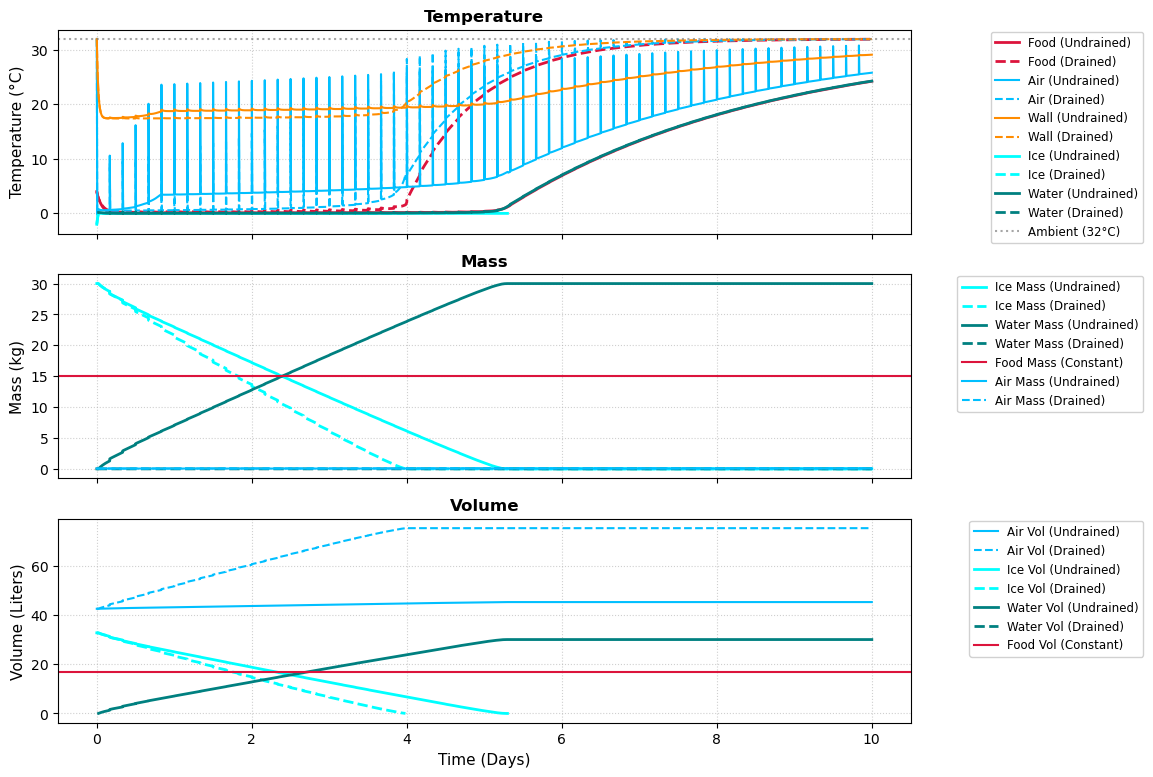

In [ ]:
t_days_dr = t_drained / 86400.0
t_days_undr = t_undrained / 86400.0


T_cooler_dr, T_air_dr, T_food_dr, T_ice_dr, T_water_dr, m_ice_dr, m_water_dr = y_drained
T_cooler_undr, T_air_undr, T_food_undr, T_ice_undr, T_water_undr, m_ice_undr, m_water_undr = y_undrained

T_ice_dr_plot = np.where(m_ice_dr > 1e-5, T_ice_dr, np.nan)
T_water_dr_plot = np.where(m_water_dr > 1e-4, T_water_dr, np.nan)

T_ice_undr_plot = np.where(m_ice_undr > 1e-5, T_ice_undr, np.nan)
T_water_undr_plot = np.where(m_water_undr > 1e-4, T_water_undr, np.nan)

V_inner_L = v_inner * 1000.0
V_food_L = (m_food / rho_food) * 1000.0

V_ice_dr_L = np.where(m_ice_dr > 1e-5, (m_ice_dr / rho_ice) * 1000.0, np.nan)
V_water_dr_L = np.where(m_water_dr > 1e-4, (m_water_dr / rho_water) * 1000.0, np.nan)
V_air_dr_L = V_inner_L - np.nan_to_num(V_ice_dr_L) - np.nan_to_num(V_water_dr_L) - V_food_L

V_ice_undr_L = np.where(m_ice_undr > 1e-5, (m_ice_undr / rho_ice) * 1000.0, np.nan)
V_water_undr_L = np.where(m_water_undr > 1e-4, (m_water_undr / rho_water) * 1000.0, np.nan)
V_air_undr_L = V_inner_L - np.nan_to_num(V_ice_undr_L) - np.nan_to_num(V_water_undr_L) - V_food_L

m_air_dr_plot = (V_air_dr_L / 1000.0) * rho_air
m_air_undr_plot = (V_air_undr_L / 1000.0) * rho_air

c_food = "crimson"
c_air = "deepskyblue"
c_wall = "darkorange"
c_ice = "cyan"
c_water = "teal"

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
##
axes[0].plot(t_days_undr, T_food_undr, color=c_food, linestyle="-", lw=2, label="Food (Undrained)")
axes[0].plot(t_days_dr, T_food_dr, color=c_food, linestyle="--", lw=2, label="Food (Drained)")

axes[0].plot(t_days_undr, T_air_undr, color=c_air, linestyle="-", lw=1.5, label="Air (Undrained)")
axes[0].plot(t_days_dr, T_air_dr, color=c_air, linestyle="--", lw=1.5, label="Air (Drained)")

axes[0].plot(t_days_undr, T_cooler_undr, color=c_wall, linestyle="-", lw=1.5, label="Wall (Undrained)")
axes[0].plot(t_days_dr, T_cooler_dr, color=c_wall, linestyle="--", lw=1.5, label="Wall (Drained)")

axes[0].plot(t_days_undr, T_ice_undr_plot, color=c_ice, linestyle="-", lw=2, label="Ice (Undrained)")
axes[0].plot(t_days_dr, T_ice_dr_plot, color=c_ice, linestyle="--", lw=2, label="Ice (Drained)")

axes[0].plot(t_days_undr, T_water_undr_plot, color=c_water, linestyle="-", lw=2, label="Water (Undrained)")
axes[0].plot(t_days_dr, T_water_dr_plot, color=c_water, linestyle="--", lw=2, label="Water (Drained)")

axes[0].axhline(T_ambient_init, color="gray", linestyle=":", alpha=0.7, label="Ambient (32°C)")
axes[0].set_ylabel("Temperature (°C)", fontsize=11)
axes[0].set_title("Temperature", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper right", bbox_to_anchor=(1.28, 1.02), framealpha=0.9, fontsize=8.5)

##
axes[1].plot(t_days_undr, m_ice_undr, color=c_ice, linestyle="-", lw=2, label="Ice Mass (Undrained)")
axes[1].plot(t_days_dr, m_ice_dr, color=c_ice, linestyle="--", lw=2, label="Ice Mass (Drained)")

axes[1].plot(t_days_undr, m_water_undr, color=c_water, linestyle="-", lw=2, label="Water Mass (Undrained)")
axes[1].plot(t_days_dr, m_water_dr, color=c_water, linestyle="--", lw=2, label="Water Mass (Drained)")

axes[1].axhline(m_food, color=c_food, linestyle="-", lw=1.5, label="Food Mass (Constant)")

axes[1].plot(t_days_undr, m_air_undr_plot, color=c_air, linestyle="-", lw=1.5, label="Air Mass (Undrained)")
axes[1].plot(t_days_dr, m_air_dr_plot, color=c_air, linestyle="--", lw=1.5, label="Air Mass (Drained)")

axes[1].set_ylabel("Mass (kg)", fontsize=11)
axes[1].set_title("Mass", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper right", bbox_to_anchor=(1.28, 1.02), framealpha=0.9, fontsize=8.5)

##
axes[2].plot(t_days_undr, V_air_undr_L, color=c_air, linestyle="-", lw=1.5, label="Air Vol (Undrained)")
axes[2].plot(t_days_dr, V_air_dr_L, color=c_air, linestyle="--", lw=1.5, label="Air Vol (Drained)")

axes[2].plot(t_days_undr, V_ice_undr_L, color=c_ice, linestyle="-", lw=2, label="Ice Vol (Undrained)")
axes[2].plot(t_days_dr, V_ice_dr_L, color=c_ice, linestyle="--", lw=2, label="Ice Vol (Drained)")

axes[2].plot(t_days_undr, V_water_undr_L, color=c_water, linestyle="-", lw=2, label="Water Vol (Undrained)")
axes[2].plot(t_days_dr, V_water_dr_L, color=c_water, linestyle="--", lw=2, label="Water Vol (Drained)")

axes[2].axhline((m_food / rho_food) * 1000.0, color=c_food, linestyle="-", lw=1.5, label="Food Vol (Constant)")

axes[2].set_xlabel("Time (Days)", fontsize=11)
axes[2].set_ylabel("Volume (Liters)", fontsize=11)
axes[2].set_title("Volume", fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="upper right", bbox_to_anchor=(1.28, 1.02), framealpha=0.9, fontsize=8.5)
plt.show()